### Mall Customer Segmentation Dataset

출처: Kaggle - Mall Customer Segmentation Data

#### 데이터셋 소개
쇼핑몰 멤버십에 가입한 고객 200명의 데이터입니다. 각 행이 고객 1명이며, 정답 라벨(타깃)이 없습니다.
정답이 없기 때문에 "몇 개의 고객 유형이 있고, 각 유형은 어떤 특징을 갖는가"를 데이터 스스로에게서 찾아내야 합니다. 이것이 비지도학습(클러스터링) 문제입니다.

#### 컬럼 설명

| 컬럼 | 설명 |
|---|---|
| `CustomerID` | 고객 고유 번호 |
| `Gender` | 성별 |
| `Age` | 나이 |
| `Annual Income (k$)` | 연간 소득 (단위: 천 달러) |
| `Spending Score (1-100)` | 쇼핑몰이 매긴 소비 점수 (구매 패턴 기반, 1~100) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [2]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### 1. 문제 정의

**목표**: 마케팅팀이 고객군별로 다른 프로모션을 적용하고 싶어한다. 소득과 소비 성향을 기준으로 고객을 몇 개의 그룹으로 나눌 수 있을까?

**입력 특성 후보**: `Age`, `Annual Income (k$)`, `Spending Score (1-100)`
**정답 라벨**: 없음 (비지도학습 — 우리가 그룹을 정의해야 함)

먼저 소득(Annual Income)과 소비 점수(Spending Score) 두 축으로 산점도를 그려서 데이터가 눈으로도 나뉘어 보이는지 확인합니다.

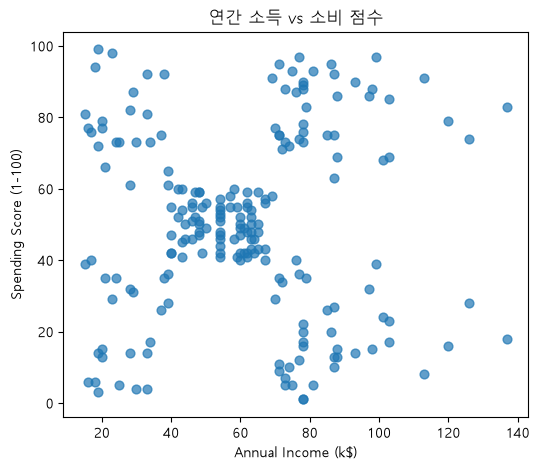

In [3]:
plt.figure(figsize=(6, 5))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], s=40, alpha=0.7)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("연간 소득 vs 소비 점수")
plt.show()

**해석 질문**: 위 산점도에서 눈으로 대략 몇 개의 덩어리(군집)가 보이나요? 소득은 낮은데 소비 점수가 높은 고객, 반대로 소득은 높은데 소비 점수가 낮은 고객은 마케팅팀 입장에서 각각 어떤 의미일까요?

#### 2. 전처리

K-means는 거리(유클리드 거리)를 기준으로 군집을 나누기 때문에, 값의 스케일이 큰 변수(예: 소득, 0~100 단위가 다른 Age)가 결과를 지배하지 않도록 **표준화(StandardScaler)** 가 필요합니다.

In [4]:
from sklearn.preprocessing import StandardScaler

features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

#### 3. Baseline 모델

일단 최선의 K를 고민하지 말고, 그래프에서 보였던 느낌대로 K=5로 K-means를 학습해 첫 번째 결과를 만들어봅니다.

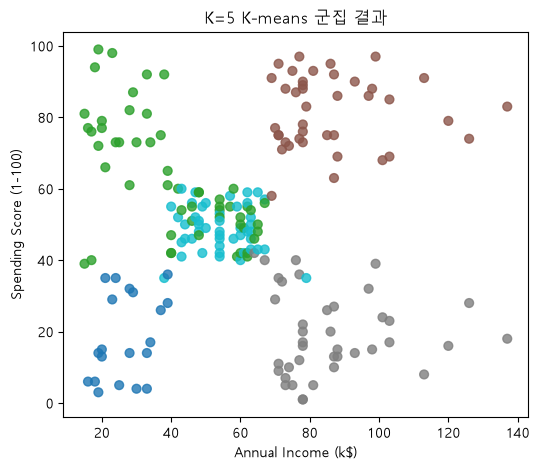

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(df["Annual Income (k$)"], df["Spending Score (1-100)"], c=df["Cluster"], cmap="tab10", s=40, alpha=0.8)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K=5 K-means 군집 결과")
plt.show()

#### 4. 지표 확인

분류/회귀와 달리 정답이 없으므로 Accuracy나 MAE를 쓸 수 없습니다. 대신 "군집이 얼마나 잘 나뉘었는가"를 아래 세 지표로 봅니다.

- **Inertia**: 각 점과 자신이 속한 군집 중심 사이 거리 제곱합. 작을수록 군집 내부가 촘촘함 (단, K를 늘리면 무조건 작아지므로 이 값만으로 K를 고르면 안 됨)
- **Silhouette Score**: -1~1. 자기 군집과는 가깝고 다른 군집과는 멀리 떨어져 있을수록 1에 가까움. 군집 개수(K)를 비교하는 데 유용
- **Dunn Index**: (군집 간 거리의 최소값) / (군집 내 요소 간 거리의 최대값). 서로 다른 군집끼리는 멀리 떨어져 있고, 같은 군집끼리는 촘촘히 모여 있을수록 값이 커짐 — 클수록 좋은 성능

Dunn Index는 scikit-learn에 내장 함수가 없어서 정의대로 직접 계산합니다.

In [6]:
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from itertools import combinations


def dunn_index(X, labels):
    clusters = [X[labels == c] for c in np.unique(labels)]
    inter_dists = [
        cdist(clusters[i], clusters[j]).min()
        for i, j in combinations(range(len(clusters)), 2)
    ]
    intra_dists = [cdist(c, c).max() for c in clusters]
    return min(inter_dists) / max(intra_dists)


print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, df["Cluster"]))
print("Dunn Index:", dunn_index(X_scaled, df["Cluster"].values))

Inertia: 168.24758017556837
Silhouette Score: 0.41664341513732767
Dunn Index: 0.0659364648066778


#### 5. Error Analysis — 이 K가 최선일까?

K=5는 감으로 고른 값입니다. K를 2~10까지 바꿔가며 Inertia(Elbow curve), Silhouette Score, Dunn Index 세 지표를 비교해서 몇 개가 가장 적절한 군집 수인지 데이터로 판단해봅니다.

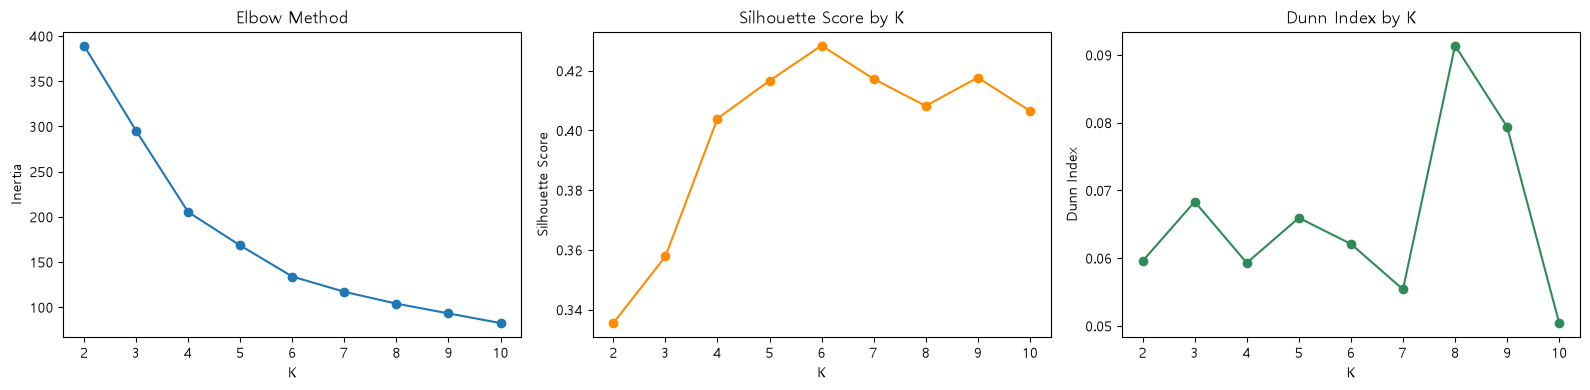

In [7]:
inertias = []
silhouettes = []
dunn_indices = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dunn_indices.append(dunn_index(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), silhouettes, marker="o", color="darkorange")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by K")

axes[2].plot(list(K_range), dunn_indices, marker="o", color="seagreen")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Dunn Index")
axes[2].set_title("Dunn Index by K")

plt.tight_layout()
plt.show()

**해석 질문**: Elbow 그래프에서 기울기가 꺾이는 지점(팔꿈치)은 어디인가요? Silhouette Score와 Dunn Index가 가장 높은 K는 각각 몇인가요? 세 지표가 같은 K를 가리키나요, 다른가요? Dunn Index는 군집 하나라도 멀리 떨어진 점(outlier)이 있으면 "군집 내 최대 거리"가 커져서 값이 크게 흔들리는 특징이 있는데, 그래프에서 그런 흔들림이 보이나요? 실제로는 여러 지표 + 비즈니스 해석(그룹 수가 너무 많으면 마케팅 전략을 세우기 어려움) 을 같이 고려해서 최종 K를 정합니다. 여기서는 K=5를 최종으로 채택합니다.

#### 6. 원인 분석 및 XAI — 각 군집은 누구인가?

분류에서는 SHAP으로 "모델이 무엇을 보고 판단했는지"를 봤습니다. 클러스터링에는 SHAP을 바로 쓸 수 없는 대신, **군집별 특성 평균(centroid 프로파일)** 을 비교해서 "이 군집을 가르는 결정적 변수가 무엇인지"를 해석합니다.

In [8]:
cluster_profile = df.groupby("Cluster")[features].mean().round(1)
cluster_profile["고객수"] = df["Cluster"].value_counts().sort_index()
cluster_profile

,Age,Annual Income (k$),Spending Score (1-100),고객수
Cluster,,,,
0,46.2,26.8,18.4,20
1,25.2,41.1,62.2,54
2,32.9,86.1,81.5,40
3,39.9,86.1,19.4,39
4,55.6,54.4,48.9,47


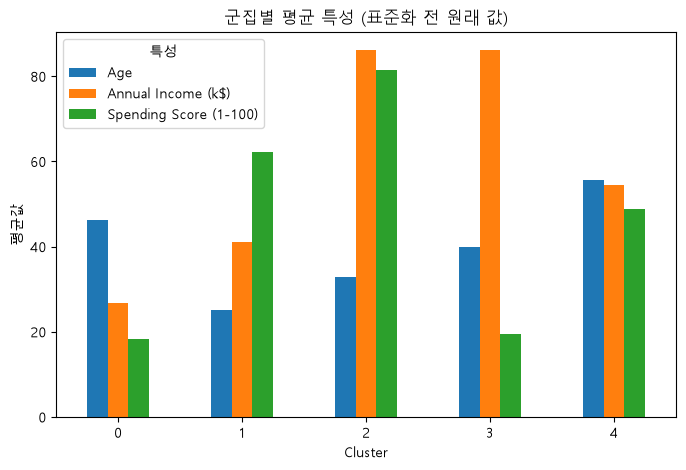

In [9]:
cluster_profile[features].plot(kind="bar", figsize=(8, 5))
plt.title("군집별 평균 특성 (표준화 전 원래 값)")
plt.ylabel("평균값")
plt.xticks(rotation=0)
plt.legend(title="특성")
plt.show()

**해석 질문**: 표와 그래프를 보고 각 군집에 이름을 붙여봅시다 (예: "고소득-고소비", "저소득-고소비", "평균적 고객" 등). 마케팅팀이라면 어떤 군집에 어떤 프로모션을 보내야 할까요?

#### 7. 차원 축소 맛보기 — PCA

지금까지 쓴 Mall Customer 데이터는 변수가 3개뿐이라 굳이 축소할 필요가 없었습니다. PCA(주성분 분석)의 진짜 위력은 **변수가 아주 많은 고차원 데이터를 압축**할 때 드러납니다. 대표적인 예로 손글씨 숫자 이미지를 씁니다 — 이미지 한 장(8×8 픽셀)이 픽셀 64개, 즉 **64개의 변수**를 가진 데이터입니다.

PCA는 "원본 데이터와의 차이(정보 손실)를 최소화하는 축(주성분)"을 순서대로 찾아서, 그 축 몇 개만으로 원래 데이터를 최대한 비슷하게 표현합니다.

데이터 shape: (1797, 64)


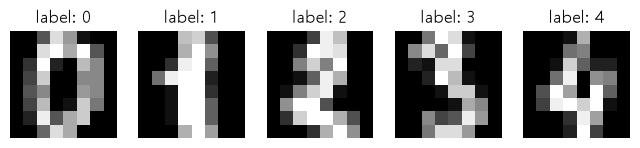

In [12]:
from sklearn.datasets import load_digits

digits = load_digits()
X_digits = digits.data      # (1797, 64) — 손글씨 숫자 1797장, 각 64차원(8x8 픽셀)
y_digits = digits.target    # 실제 숫자 0~9 (여기서는 눈으로 확인용으로만 사용, 학습엔 안 씀)

print("데이터 shape:", X_digits.shape)

fig, axes = plt.subplots(1, 5, figsize=(8, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap="gray")
    ax.set_title(f"label: {y_digits[i]}")
    ax.axis("off")
plt.show()

64차원 데이터는 산점도로 그릴 수 없습니다(축이 64개 필요). PCA로 2차원까지 압축해서 눈으로 볼 수 있게 만들어봅니다.

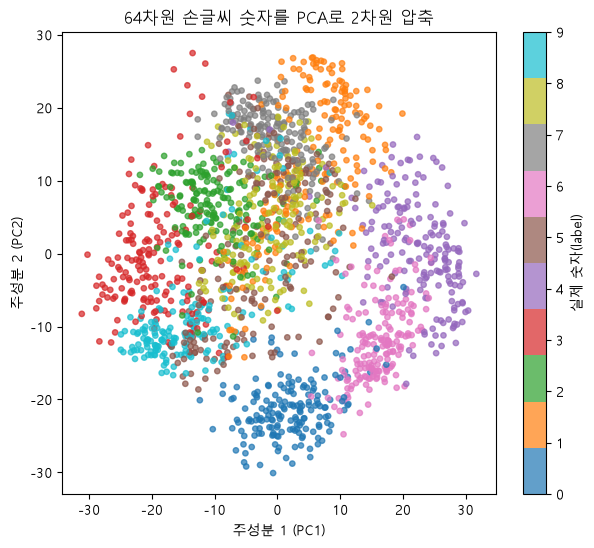

주성분 2개가 설명하는 원본 정보 비율: 0.285


In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_digits)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_digits, cmap="tab10", s=15, alpha=0.7)
plt.xlabel("주성분 1 (PC1)")
plt.ylabel("주성분 2 (PC2)")
plt.title("64차원 손글씨 숫자를 PCA로 2차원 압축")
plt.colorbar(scatter, label="실제 숫자(label)")
plt.show()

print("주성분 2개가 설명하는 원본 정보 비율:", pca.explained_variance_ratio_.sum().round(3))

**해석 질문**: 64개였던 변수를 2개로 줄였는데도(정보를 20~30%만 남겼는데도) 같은 숫자끼리 어느 정도 뭉쳐 보이나요? 어떤 숫자끼리는 겹쳐서 헷갈리나요? (색은 정답 라벨이고, PCA 자체는 라벨을 전혀 보지 않고 압축했다는 점에 주목하세요.)

몇 개의 주성분이면 원본 정보를 충분히 유지할 수 있을까요? 주성분 개수를 늘려가며 누적 설명 비율을 확인해봅니다.

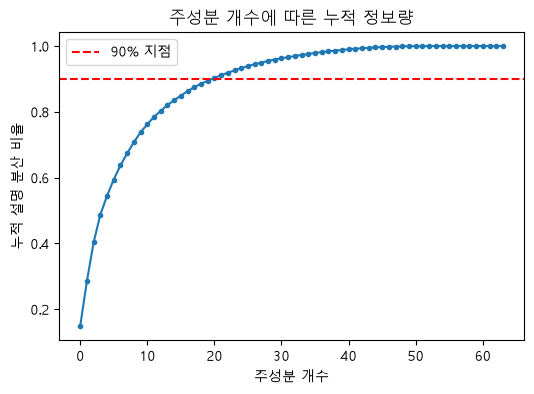

90% 정보를 유지하는 데 필요한 주성분 개수: 21개 (원래 64개)


In [14]:
pca_full = PCA().fit(X_digits)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(cum_var, marker=".")
plt.axhline(0.9, color="red", linestyle="--", label="90% 지점")
plt.xlabel("주성분 개수")
plt.ylabel("누적 설명 분산 비율")
plt.title("주성분 개수에 따른 누적 정보량")
plt.legend()
plt.show()

n_needed = np.argmax(cum_var >= 0.9) + 1
print(f"90% 정보를 유지하는 데 필요한 주성분 개수: {n_needed}개 (원래 64개)")

**해석 질문**: 64개 중 몇 개의 주성분으로 정보의 90%를 유지할 수 있나요? 이 결과가 "대용량 고차원 데이터를 압축해서 저장·연산 비용을 줄인다"는 PCA의 쓸모와 어떻게 연결되나요?

#### 10. PCA + 클러스터링 이어붙이기

앞에서 배운 K-means를 PCA로 압축한 2차원 데이터에 그대로 적용해봅니다. 이번엔 **정답 숫자를 전혀 보여주지 않고** 순수하게 좌표만으로 10개 그룹으로 나눈 뒤, 각 그룹에 실제로 어떤 숫자가 많이 섞여 있는지 사후에만 확인합니다.

In [15]:
import pandas as pd

km_digits = KMeans(n_clusters=10, random_state=42, n_init=10)
digit_clusters = km_digits.fit_predict(X_pca)

crosstab = pd.crosstab(digit_clusters, y_digits)
crosstab.index.name = "K-means 군집"
crosstab.columns.name = "실제 숫자"
crosstab

실제 숫자,0,1,2,3,4,5,6,7,8,9
K-means 군집,,,,,,,,,,
0,1,28,36,11,0,45,0,1,72,16
1,0,86,0,0,5,0,0,21,4,0
2,1,2,0,0,151,2,27,0,1,0
3,4,7,4,20,0,48,0,0,9,78
4,15,0,0,0,16,5,145,0,0,1
5,0,0,0,90,0,0,0,0,0,57
6,157,0,0,0,0,5,7,0,0,0
7,0,9,13,13,3,27,0,117,27,9
8,0,50,11,0,6,46,2,40,58,10


**해석 질문**: 표에서 각 행(군집)마다 숫자 하나가 압도적으로 많이 몰려 있나요, 아니면 여러 숫자가 고르게 섞여 있나요? 라벨을 전혀 쓰지 않은 K-means가 실제 숫자 구분과 얼마나 비슷하게 그룹을 만들었는지, 그리고 어떤 숫자쌍(예: 3과 8, 4와 9)이 잘 안 갈리는지 앞의 PCA 산점도와 비교해서 이야기해봅시다.